# 06 Model Evaluation & Ensemble — Women's

Two responsibilities:
1. **Individual model evaluation** — compare Brier scores, calibration curves, and prediction distributions across all 4 models
2. **Ensemble construction** — build a weighted ensemble that minimizes Brier score, then generate final predictions for Stage 1 and Stage 2

**Inputs** (from S3 `05_models/{model}/womens/`):
- `oof_predictions.parquet` from each model (XGBoost, LightGBM, CatBoost, PyTorch)
- `stage1_predictions.parquet` from each model
- `stage2_predictions.parquet` from each model
- `cv_results.parquet` from each model

**Outputs** (to S3 `06_model_eval/womens/`):
- `ensemble_stage1_predictions.parquet` — final ensemble predictions for Stage 1
- `ensemble_stage2_predictions.parquet` — final ensemble predictions for Stage 2
- `ensemble_weights.parquet` — optimized model weights
- `model_comparison.parquet` — side-by-side Brier scores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.optimize import minimize

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

#### Functions

In [2]:
def read_model_parquet(model_name, filename):
    """Read parquet from a model's S3 output or local."""
    try:
        return pd.read_parquet(f"s3://{BUCKET}/05_models/{model_name}/{GENDER}/{filename}")
    except Exception:
        return pd.read_parquet(f"../05_models/{model_name}/output/{filename}")

def save_plot(fig, name):
    """Save plot to local output directory with gender prefix."""
    fig.savefig(f"{LOCAL_OUTPUT}{GENDER}_{name}.png", bbox_inches='tight', dpi=150)
    print(f"Saved: {LOCAL_OUTPUT}{GENDER}_{name}.png")

In [3]:
def ensemble_brier(weights, pred_matrix, labels, sample_weights=None):
    """Compute Brier score for a weighted ensemble, optionally with sample weights."""
    weights = np.array(weights)
    weights = weights / weights.sum()  # normalize
    ensemble_preds = pred_matrix @ weights
    if sample_weights is not None:
        return np.average((ensemble_preds - labels) ** 2, weights=sample_weights)
    return np.mean((ensemble_preds - labels) ** 2)

def optimize_ensemble_weights(pred_matrix, labels, n_models, sample_weights=None):
    """Find weights that minimize Brier score on OOF predictions.
    
    If sample_weights is provided, recent seasons are weighted more heavily
    in the optimization, so the ensemble favors accuracy on modern basketball.
    """
    # Start with equal weights
    x0 = np.ones(n_models) / n_models
    
    # Constraints: weights sum to 1, each weight >= 0
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n_models
    
    result = minimize(
        ensemble_brier,
        x0,
        args=(pred_matrix, labels, sample_weights),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

#### Constants

In [4]:
BUCKET = "march-machine-learning-mania-2026"
GENDER = "womens"
STAGE = "06_model_eval"
OUTPUT_PREFIX = f"s3://{BUCKET}/{STAGE}/{GENDER}/"

LOCAL_OUTPUT = "output/"

MODELS = ['catboost', 'pytorch', 'logistic_regression']

#### Make output directory

In [5]:
os.makedirs(LOCAL_OUTPUT, exist_ok=True)

## 1. Load All Model Predictions

In [6]:
# Load OOF predictions from each model
oof_dfs = {}
cv_dfs = {}
stage1_dfs = {}
stage2_dfs = {}

for model in MODELS:
    oof_dfs[model] = read_model_parquet(model, 'oof_predictions.parquet')
    cv_dfs[model] = read_model_parquet(model, 'cv_results.parquet')
    stage1_dfs[model] = read_model_parquet(model, 'stage1_predictions.parquet')
    stage2_dfs[model] = read_model_parquet(model, 'stage2_predictions.parquet')
    print(f"Loaded {model}: OOF={oof_dfs[model].shape}, Stage1={stage1_dfs[model].shape}, Stage2={stage2_dfs[model].shape}")

Loaded catboost: OOF=(1717, 9), Stage1=(258131, 7), Stage2=(65703, 6)
Loaded pytorch: OOF=(1717, 9), Stage1=(258131, 7), Stage2=(65703, 6)
Loaded logistic_regression: OOF=(1717, 9), Stage1=(258131, 7), Stage2=(65703, 6)


## 2. Individual Model Comparison

In [7]:
# Compute Brier scores for each model
comparison = []

for model in MODELS:
    oof = oof_dfs[model]
    overall_brier = brier_score_loss(oof['Label'], oof['Pred'])
    calibrated_brier = brier_score_loss(oof['Label'], oof['PredCalibrated'])
    
    stage1_oof = oof[oof['IsStage1Val'] == 1]
    stage1_brier = brier_score_loss(stage1_oof['Label'], stage1_oof['Pred']) if len(stage1_oof) > 0 else None
    stage1_cal_brier = brier_score_loss(stage1_oof['Label'], stage1_oof['PredCalibrated']) if len(stage1_oof) > 0 else None
    
    cv = cv_dfs[model]
    
    comparison.append({
        'Model': model,
        'OOF_Brier_Raw': overall_brier,
        'OOF_Brier_Calibrated': calibrated_brier,
        'Stage1_Brier_Raw': stage1_brier,
        'Stage1_Brier_Calibrated': stage1_cal_brier,
        'CV_Mean_Brier': np.average(cv.sort_values('Fold')['BrierScore'], weights=np.arange(1, len(cv) + 1)),
    })

comparison_df = pd.DataFrame(comparison).sort_values('OOF_Brier_Calibrated')
print("Model Comparison (sorted by OOF Brier Calibrated):")
print(comparison_df.to_string(index=False))

Model Comparison (sorted by OOF Brier Calibrated):
              Model  OOF_Brier_Raw  OOF_Brier_Calibrated  Stage1_Brier_Raw  Stage1_Brier_Calibrated  CV_Mean_Brier
            pytorch       0.135275              0.131293          0.128947                 0.130304       0.133161
           catboost       0.142068              0.137820          0.131832                 0.128748       0.140399
logistic_regression       0.141455              0.137893          0.140448                 0.135801       0.139939


## 3. Brier Score Bar Chart

Saved: output/womens_model_brier_comparison.png


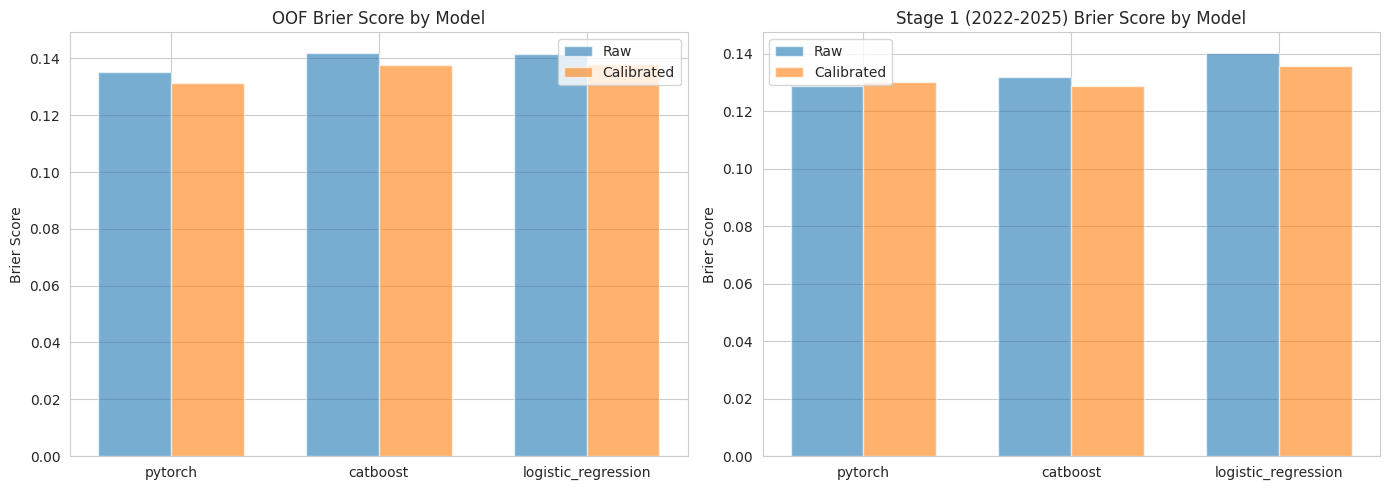

In [8]:
# Bar chart of Brier scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OOF Brier
x = range(len(comparison_df))
axes[0].bar(x, comparison_df['OOF_Brier_Raw'], alpha=0.6, label='Raw', width=0.35)
axes[0].bar([i + 0.35 for i in x], comparison_df['OOF_Brier_Calibrated'], alpha=0.6, label='Calibrated', width=0.35)
axes[0].set_xticks([i + 0.175 for i in x])
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].set_ylabel('Brier Score')
axes[0].set_title('OOF Brier Score by Model')
axes[0].legend()

# Stage 1 Brier
axes[1].bar(x, comparison_df['Stage1_Brier_Raw'], alpha=0.6, label='Raw', width=0.35)
axes[1].bar([i + 0.35 for i in x], comparison_df['Stage1_Brier_Calibrated'], alpha=0.6, label='Calibrated', width=0.35)
axes[1].set_xticks([i + 0.175 for i in x])
axes[1].set_xticklabels(comparison_df['Model'])
axes[1].set_ylabel('Brier Score')
axes[1].set_title('Stage 1 (2022-2025) Brier Score by Model')
axes[1].legend()

plt.tight_layout()
save_plot(fig, 'model_brier_comparison')
plt.show()

## 4. Calibration Curves

A well-calibrated model should have predicted probabilities that match observed frequencies. Points should fall on the diagonal.

Saved: output/womens_calibration_curves.png


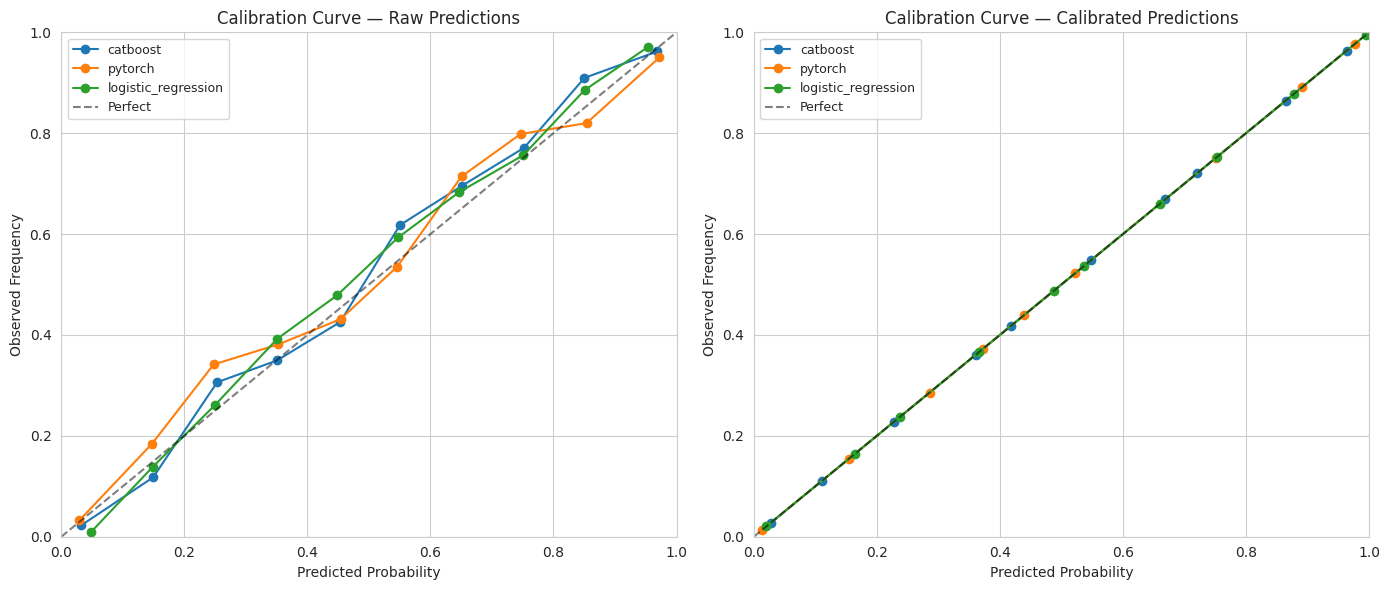

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for model in MODELS:
    oof = oof_dfs[model]
    
    # Raw predictions
    prob_true, prob_pred = calibration_curve(oof['Label'], oof['Pred'], n_bins=10)
    axes[0].plot(prob_pred, prob_true, 'o-', label=model)
    
    # Calibrated predictions
    prob_true_cal, prob_pred_cal = calibration_curve(oof['Label'], oof['PredCalibrated'], n_bins=10)
    axes[1].plot(prob_pred_cal, prob_true_cal, 'o-', label=model)

for ax, title in zip(axes, ['Raw Predictions', 'Calibrated Predictions']):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Observed Frequency')
    ax.set_title(f'Calibration Curve — {title}')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
save_plot(fig, 'calibration_curves')
plt.show()

## 5. Prediction Distribution Comparison

Saved: output/womens_prediction_distributions.png


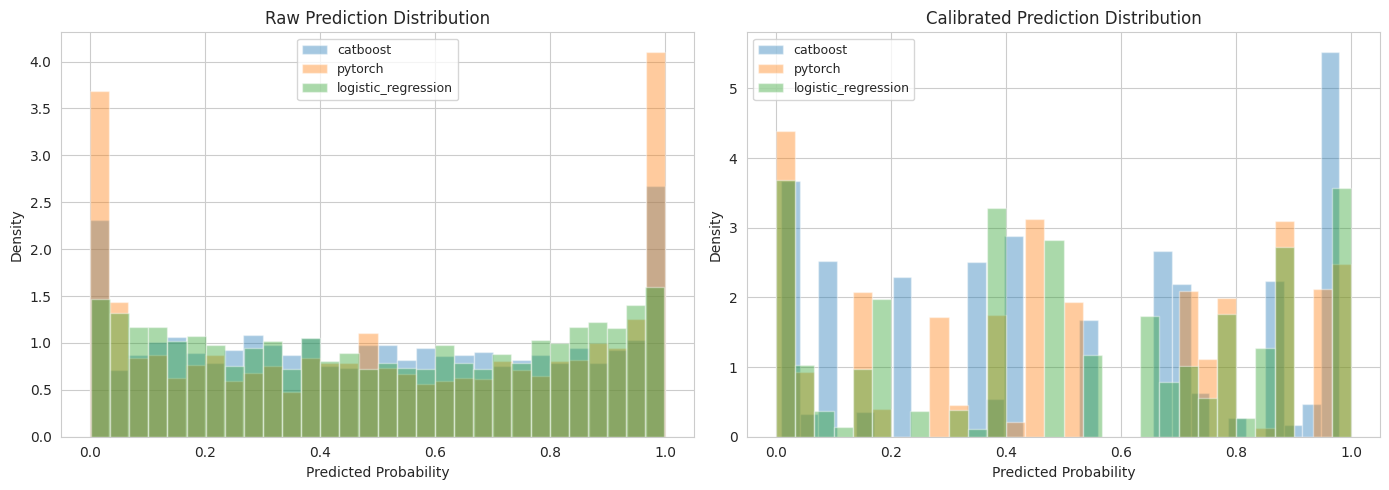

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model in MODELS:
    oof = oof_dfs[model]
    axes[0].hist(oof['Pred'], bins=30, alpha=0.4, label=model, density=True)
    axes[1].hist(oof['PredCalibrated'], bins=30, alpha=0.4, label=model, density=True)

axes[0].set_title('Raw Prediction Distribution')
axes[1].set_title('Calibrated Prediction Distribution')
for ax in axes:
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
save_plot(fig, 'prediction_distributions')
plt.show()

## 6. Per-Fold Brier Score Comparison

Saved: output/womens_per_fold_brier.png


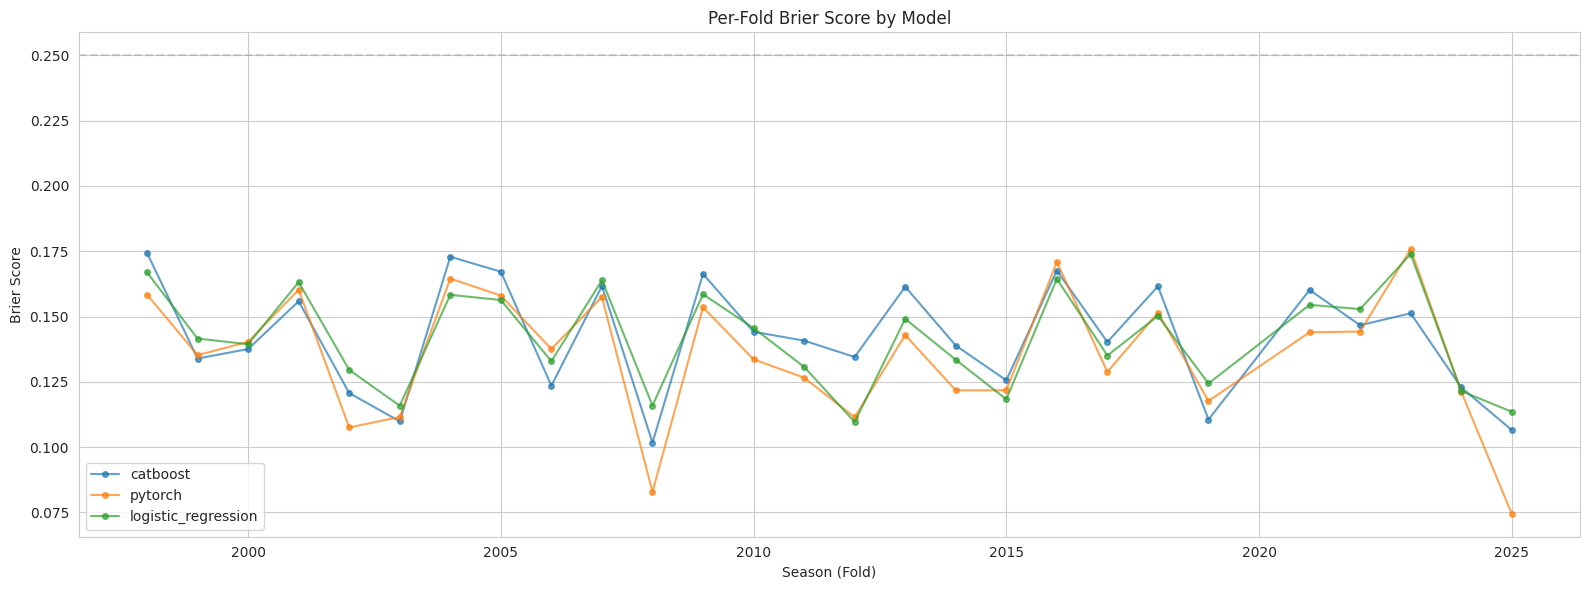

In [11]:
# Merge CV results across models
cv_all = cv_dfs[MODELS[0]][['Fold']].copy()
for model in MODELS:
    cv_all = cv_all.merge(
        cv_dfs[model][['Fold', 'BrierScore']].rename(columns={'BrierScore': model}),
        on='Fold', how='outer'
    )

fig, ax = plt.subplots(figsize=(16, 6))
for model in MODELS:
    ax.plot(cv_all['Fold'], cv_all[model], 'o-', alpha=0.7, label=model, markersize=4)

ax.set_xlabel('Season (Fold)')
ax.set_ylabel('Brier Score')
ax.set_title('Per-Fold Brier Score by Model')
ax.legend()
ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.3, label='Naive (0.25)')
plt.tight_layout()
save_plot(fig, 'per_fold_brier')
plt.show()

## 7. Model Correlation

Diversity matters for ensembling. If models are highly correlated, ensembling provides less benefit.

Saved: output/womens_model_correlation.png


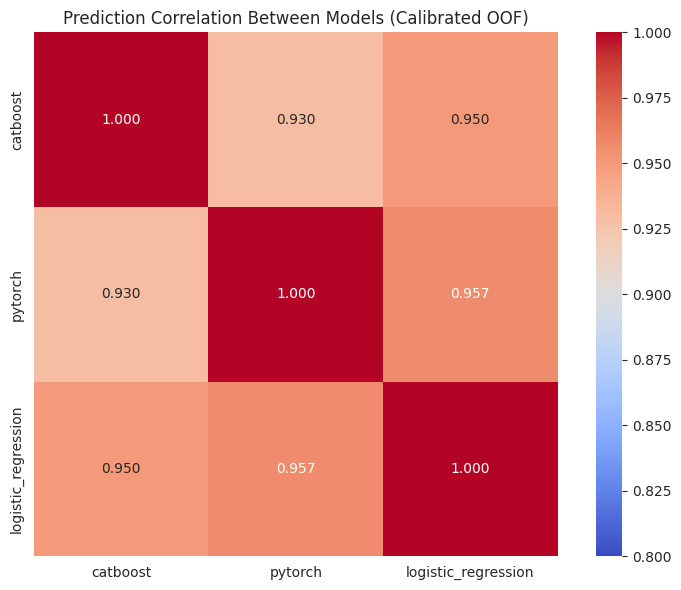

In [12]:
# Merge OOF predictions from all models on ID
oof_merged = oof_dfs[MODELS[0]][['ID', 'Label', 'Season']].copy()
for model in MODELS:
    oof_merged = oof_merged.merge(
        oof_dfs[model][['ID', 'PredCalibrated']].rename(columns={'PredCalibrated': model}),
        on='ID', how='inner'
    )

pred_corr = oof_merged[MODELS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pred_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0.9,
            vmin=0.8, vmax=1.0, ax=ax, square=True)
ax.set_title('Prediction Correlation Between Models (Calibrated OOF)')
plt.tight_layout()
save_plot(fig, 'model_correlation')
plt.show()

## 8. Optimize Ensemble Weights

Find the weighted average of model predictions that minimizes Brier score on OOF data.

In [13]:
# Build prediction matrix (N x M)
pred_matrix = oof_merged[MODELS].values
labels = oof_merged['Label'].values

# Build recency weights: linearly increasing by season
# e.g., 1998 gets weight 1, 1999 gets weight 2, ..., 2025 gets weight 27
seasons = oof_merged['Season'].values
unique_seasons = np.sort(np.unique(seasons))
season_to_weight = {s: i + 1 for i, s in enumerate(unique_seasons)}
sample_weights = np.array([season_to_weight[s] for s in seasons], dtype=float)

print(f"Recency weighting: {unique_seasons[0]} gets weight {season_to_weight[unique_seasons[0]]}, "
      f"{unique_seasons[-1]} gets weight {season_to_weight[unique_seasons[-1]]}")
print(f"Most recent season is weighted {season_to_weight[unique_seasons[-1]] / season_to_weight[unique_seasons[0]]}x more than the oldest")

# Optimize weights with recency weighting
opt_weights = optimize_ensemble_weights(pred_matrix, labels, len(MODELS), sample_weights=sample_weights)

# Also compute unweighted for comparison
opt_weights_unweighted = optimize_ensemble_weights(pred_matrix, labels, len(MODELS), sample_weights=None)

print(f"\nOptimized Ensemble Weights (recency-weighted):")
for model, weight in zip(MODELS, opt_weights):
    print(f"  {model:15s}: {weight:.4f}")

print(f"\nFor comparison — unweighted:")
for model, weight in zip(MODELS, opt_weights_unweighted):
    print(f"  {model:15s}: {weight:.4f}")

# Compute ensemble OOF Brier (unweighted Brier for fair comparison)
oof_merged['Ensemble'] = pred_matrix @ opt_weights
ensemble_brier_score = brier_score_loss(labels, oof_merged['Ensemble'])

# Also compute equal-weight ensemble for comparison
equal_weights = np.ones(len(MODELS)) / len(MODELS)
oof_merged['EqualEnsemble'] = pred_matrix @ equal_weights
equal_brier = brier_score_loss(labels, oof_merged['EqualEnsemble'])

print(f"\nEnsemble OOF Brier (recency-weighted optimization): {ensemble_brier_score:.4f}")
print(f"Ensemble OOF Brier (equal weights):                  {equal_brier:.4f}")
print(f"Best single model (calibrated):                       {comparison_df['OOF_Brier_Calibrated'].min():.4f}")

Recency weighting: 1998 gets weight 1, 2025 gets weight 27
Most recent season is weighted 27.0x more than the oldest

Optimized Ensemble Weights (recency-weighted):
  catboost       : 0.3324
  pytorch        : 0.6676
  logistic_regression: 0.0000

For comparison — unweighted:
  catboost       : 0.2971
  pytorch        : 0.7029
  logistic_regression: 0.0000

Ensemble OOF Brier (recency-weighted optimization): 0.1299
Ensemble OOF Brier (equal weights):                  0.1315
Best single model (calibrated):                       0.1313


## 9. Evaluate Ensemble on Stage 1 (2022-2025)

In [14]:
# Evaluate ensemble on Stage 1 (2022-2025) subset
stage1_mask = oof_merged['ID'].str.startswith(('2022_', '2023_', '2024_', '2025_'))
if stage1_mask.any():
    s1 = oof_merged[stage1_mask]
    s1_ensemble_brier = brier_score_loss(s1['Label'], s1['Ensemble'])
    s1_equal_brier = brier_score_loss(s1['Label'], s1['EqualEnsemble'])
    print(f"Stage 1 Ensemble Brier (optimized): {s1_ensemble_brier:.4f}")
    print(f"Stage 1 Ensemble Brier (equal):     {s1_equal_brier:.4f}")
    
    # Compare to individual models on Stage 1
    print(f"\nStage 1 individual model Brier scores (calibrated):")
    for model in MODELS:
        s1_brier = brier_score_loss(s1['Label'], s1[model])
        print(f"  {model:15s}: {s1_brier:.4f}")

Stage 1 Ensemble Brier (optimized): 0.1244
Stage 1 Ensemble Brier (equal):     0.1253

Stage 1 individual model Brier scores (calibrated):
  catboost       : 0.1287
  pytorch        : 0.1303
  logistic_regression: 0.1358


## 10. Generate Ensemble Predictions for Stage 1 & Stage 2

In [15]:
# Stage 1 ensemble
stage1_merged = stage1_dfs[MODELS[0]][['ID', 'Season', 'TeamA', 'TeamB']].copy()
if 'Label' in stage1_dfs[MODELS[0]].columns:
    stage1_merged['Label'] = stage1_dfs[MODELS[0]]['Label']

for model in MODELS:
    pred_col = f'Pred_{model}_calibrated'
    stage1_merged[model] = stage1_dfs[model][pred_col].values

stage1_merged['Pred'] = stage1_merged[MODELS].values @ opt_weights
stage1_merged['Pred'] = stage1_merged['Pred'].clip(0.02, 0.98)

print(f"Stage 1 ensemble predictions: {stage1_merged.shape}")
print(f"  Pred range: [{stage1_merged['Pred'].min():.3f}, {stage1_merged['Pred'].max():.3f}]")
print(f"  Pred mean: {stage1_merged['Pred'].mean():.3f}")

# Evaluate on actual Stage 1 games
if 'Label' in stage1_merged.columns:
    s1_actual = stage1_merged.dropna(subset=['Label'])
    if len(s1_actual) > 0:
        s1_brier = brier_score_loss(s1_actual['Label'], s1_actual['Pred'])
        print(f"  Stage 1 Brier (ensemble): {s1_brier:.4f}")

Stage 1 ensemble predictions: (258131, 9)
  Pred range: [0.020, 0.980]
  Pred mean: 0.565
  Stage 1 Brier (ensemble): 0.1196


In [16]:
# Stage 2 ensemble
stage2_merged = stage2_dfs[MODELS[0]][['ID', 'Season', 'TeamA', 'TeamB']].copy()

for model in MODELS:
    pred_col = f'Pred_{model}_calibrated'
    stage2_merged[model] = stage2_dfs[model][pred_col].values

stage2_merged['Pred'] = stage2_merged[MODELS].values @ opt_weights
stage2_merged['Pred'] = stage2_merged['Pred'].clip(0.02, 0.98)

print(f"Stage 2 ensemble predictions: {stage2_merged.shape}")
print(f"  Pred range: [{stage2_merged['Pred'].min():.3f}, {stage2_merged['Pred'].max():.3f}]")
print(f"  Pred mean: {stage2_merged['Pred'].mean():.3f}")

Stage 2 ensemble predictions: (65703, 8)
  Pred range: [0.020, 0.980]
  Pred mean: 0.562


## 11. Save Outputs

In [17]:
# Save ensemble weights
weights_df = pd.DataFrame({'Model': MODELS, 'Weight': opt_weights})

outputs = {
    'ensemble_stage1_predictions': stage1_merged[['ID', 'Season', 'TeamA', 'TeamB', 'Pred'] + (['Label'] if 'Label' in stage1_merged.columns else [])],
    'ensemble_stage2_predictions': stage2_merged[['ID', 'Season', 'TeamA', 'TeamB', 'Pred']],
    'ensemble_weights': weights_df,
    'model_comparison': comparison_df,
}

for name, df in outputs.items():
    try:
        s3_path = f"{OUTPUT_PREFIX}{name}.parquet"
        df.to_parquet(s3_path, index=False)
        print(f"Saved to S3: {s3_path} ({df.shape})")
    except Exception as e:
        print(f"S3 save failed for {name}: {e}")

Saved to S3: s3://march-machine-learning-mania-2026/06_model_eval/womens/ensemble_stage1_predictions.parquet ((258131, 6))
Saved to S3: s3://march-machine-learning-mania-2026/06_model_eval/womens/ensemble_stage2_predictions.parquet ((65703, 5))
Saved to S3: s3://march-machine-learning-mania-2026/06_model_eval/womens/ensemble_weights.parquet ((3, 2))
Saved to S3: s3://march-machine-learning-mania-2026/06_model_eval/womens/model_comparison.parquet ((3, 6))


## 12. Summary

In [18]:
print("=" * 60)
print("MODEL EVALUATION & ENSEMBLE SUMMARY — WOMEN'S")
print("=" * 60)

print("\nIndividual Model Brier Scores (calibrated OOF):")
for _, row in comparison_df.iterrows():
    print(f"  {row['Model']:15s}: {row['OOF_Brier_Calibrated']:.4f}")

print(f"\nEnsemble Weights:")
for model, weight in zip(MODELS, opt_weights):
    print(f"  {model:15s}: {weight:.4f}")

print(f"\nEnsemble Brier Scores:")
print(f"  OOF (optimized):  {ensemble_brier_score:.4f}")
print(f"  OOF (equal):      {equal_brier:.4f}")
print(f"  Best single:      {comparison_df['OOF_Brier_Calibrated'].min():.4f}")
print(f"  Ensemble gain:    {comparison_df['OOF_Brier_Calibrated'].min() - ensemble_brier_score:+.4f}")

MODEL EVALUATION & ENSEMBLE SUMMARY — WOMEN'S

Individual Model Brier Scores (calibrated OOF):
  pytorch        : 0.1313
  catboost       : 0.1378
  logistic_regression: 0.1379

Ensemble Weights:
  catboost       : 0.3324
  pytorch        : 0.6676
  logistic_regression: 0.0000

Ensemble Brier Scores:
  OOF (optimized):  0.1299
  OOF (equal):      0.1315
  Best single:      0.1313
  Ensemble gain:    +0.0014
